In [11]:
import os

data_folder = '../data'

for filename in os.listdir(data_folder):
    if filename.endswith('.csv'):
        path = os.path.join(data_folder, filename)
        with open(path, 'r') as f:
            lines = f.readlines()
        print(f"\n--- {filename} ---")
        print(f"First 3 lines:")
        for line in lines[:3]:
            print(repr(line))


--- commodity_adj.csv ---
First 3 lines:
'commodity,vol_pct,adj_bps\n'
'Copper,14.819684396532596,0\n'
'Iron Ore,20.401433305887355,21\n'

--- corridor_map.csv ---
First 3 lines:
'corridor,fx_code,fx_pair\n'
'Asia to Europe,DEXINUS,USD/INR\n'
'Americas to Asia,DEXCHUS,USD/CNY\n'

--- DBAA.csv ---
First 3 lines:
'observation_date,DBAA\n'
'1986-01-02,11.38\n'
'1986-01-03,11.35\n'

--- DEXCHUS.csv ---
First 3 lines:
'observation_date,DEXCHUS\n'
'1981-01-02,1.5341\n'
'1981-01-05,1.5418\n'

--- DEXINUS.csv ---
First 3 lines:
'observation_date,DEXINUS\n'
'1973-01-02,8.0200\n'
'1973-01-03,8.0200\n'

--- DEXMXUS.csv ---
First 3 lines:
'observation_date,DEXMXUS\n'
'1993-11-08,3.1520\n'
'1993-11-09,3.2400\n'

--- DEXSFUS.csv ---
First 3 lines:
'observation_date,DEXSFUS\n'
'1980-01-02,0.8271\n'
'1980-01-03,0.8271\n'

--- DEXUSEU.csv ---
First 3 lines:
'observation_date,DEXUSEU\n'
'1999-01-04,1.1812\n'
'1999-01-05,1.1760\n'

--- DGS3MO.csv ---
First 3 lines:
'observation_date,DGS3MO\n'
'1981-09-0

In [12]:
import pandas as pd
import os

data_folder = '../data'

skip_files = ['fred_raw.csv']

frames = {}
for filename in os.listdir(data_folder):
    if filename.endswith('.csv') and filename not in skip_files:
        code = filename.replace('.csv', '')
        path = os.path.join(data_folder, filename)
        df_temp = pd.read_csv(
            path,
            parse_dates=['observation_date'],
            index_col='observation_date'
        )
        df_temp.replace('.', float('nan'), inplace=True)
        df_temp = df_temp.astype(float)
        df_temp = df_temp[df_temp.index >= '2005-01-01']
        frames[code] = df_temp
        print(f"{code}: {len(df_temp)} rows | {df_temp.index[0].date()} to {df_temp.index[-1].date()}")

df = pd.concat(frames.values(), axis=1)
df.index.name = 'date'
df.to_csv('../data/fred_master.csv')
print(f"\nMaster file shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.tail(3))

ValueError: Missing column provided to 'parse_dates': 'observation_date'

C:\Users\imman\AppData\Local\Temp\ipykernel_11912\1866637863.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['DXY_30D_CHANGE'] = df['DTWEXBGS'].pct_change(30) * 100


Credit Spread stats:
count    5329.00
mean        3.62
std         1.86
min        -0.01
25%         2.21
50%         3.42
75%         5.07
max         9.16
Name: CREDIT_SPREAD, dtype: float64

Spread today (approx): 2.38%


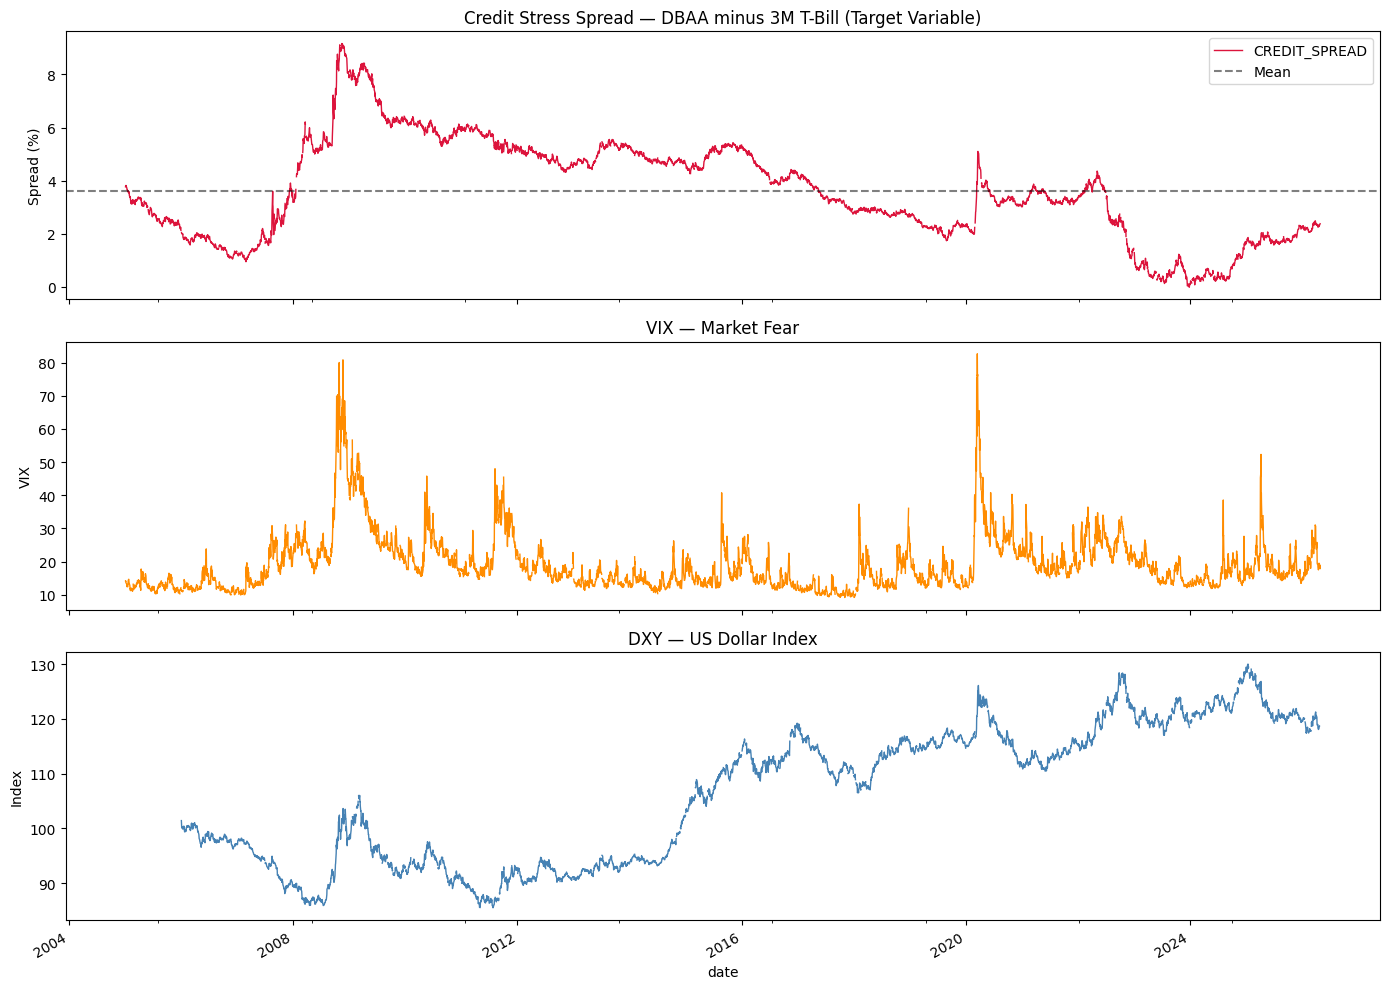


Chart saved to data/macro_overview.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')

# Create the target variable: credit stress spread
df['CREDIT_SPREAD'] = df['DBAA'] - df['DGS3MO']

# Create your first engineered feature: dollar momentum
df['DXY_30D_CHANGE'] = df['DTWEXBGS'].pct_change(30) * 100

# Forward-fill monthly series to daily
df['FEDFUNDS'] = df['FEDFUNDS'].ffill()
df['M2SL'] = df['M2SL'].ffill()

# Save the enriched file
df.to_csv('../data/fred_master.csv')

# Quick sanity check - print the key stats
print("Credit Spread stats:")
print(df['CREDIT_SPREAD'].describe().round(2))
print(f"\nSpread today (approx): {df['CREDIT_SPREAD'].dropna().iloc[-1]:.2f}%")

# Plot it
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

df['CREDIT_SPREAD'].plot(ax=axes[0], color='crimson', linewidth=1)
axes[0].set_title('Credit Stress Spread — DBAA minus 3M T-Bill (Target Variable)')
axes[0].set_ylabel('Spread (%)')
axes[0].axhline(y=df['CREDIT_SPREAD'].mean(), color='black', linestyle='--', alpha=0.5, label='Mean')
axes[0].legend()

df['VIXCLS'].plot(ax=axes[1], color='darkorange', linewidth=1)
axes[1].set_title('VIX — Market Fear')
axes[1].set_ylabel('VIX')

df['DTWEXBGS'].plot(ax=axes[2], color='steelblue', linewidth=1)
axes[2].set_title('DXY — US Dollar Index')
axes[2].set_ylabel('Index')

plt.tight_layout()
plt.savefig('../data/macro_overview.png', dpi=150)
plt.show()
print("\nChart saved to data/macro_overview.png")

Model dataset: (841, 12)
Date range: 2006-03-31 to 2025-10-10

Train: up to 2019-05-22
Test:  2019-05-22 onwards

Test MAE:  0.622%  (average prediction error in spread %)
Test R²:   0.660   (1.0 = perfect, 0.0 = no skill)


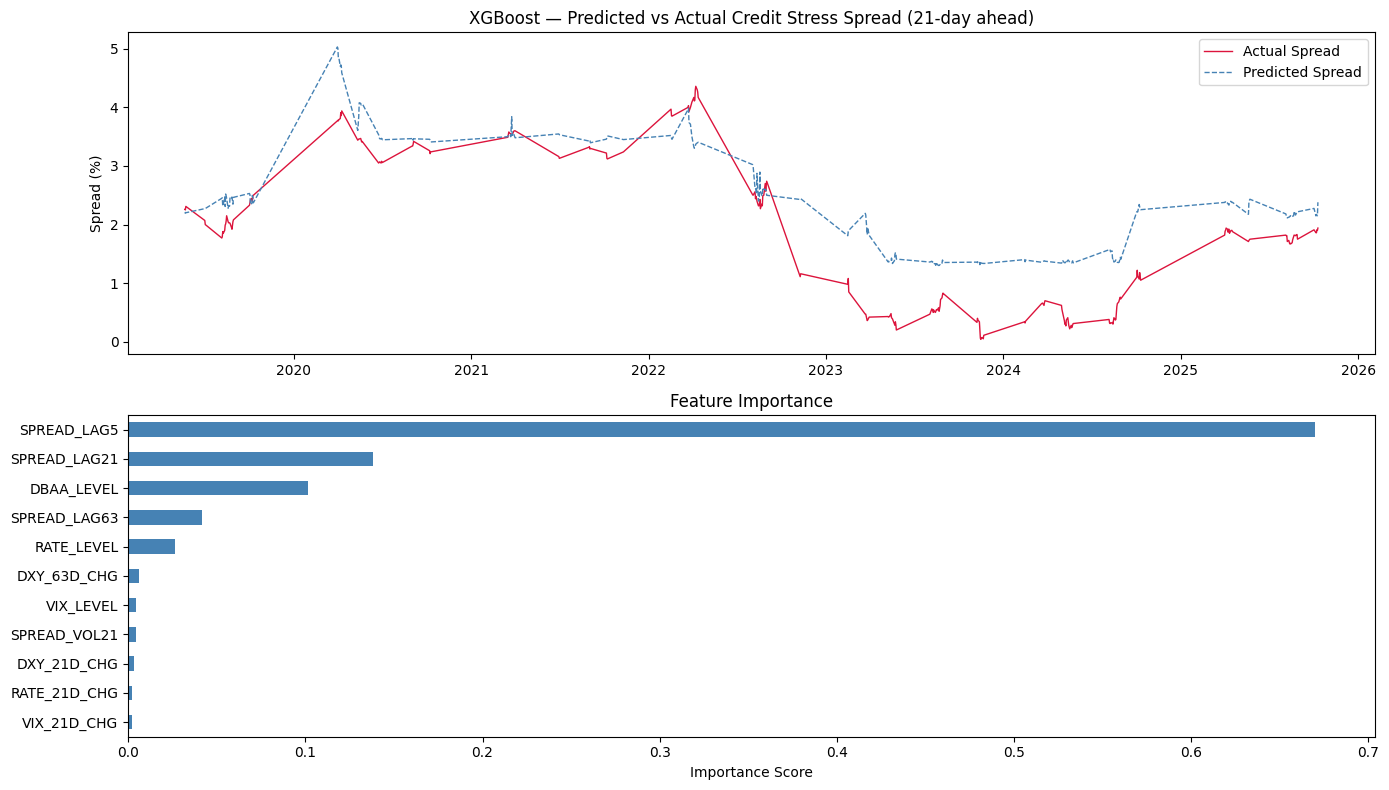


Chart saved.
Model saved to data/xgboost_model.pkl


In [14]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')

# ── Feature Engineering ──────────────────────────────────────────────────────

# Lagged credit spread (where we've been)
df['SPREAD_LAG5']  = df['CREDIT_SPREAD'].shift(5)
df['SPREAD_LAG21'] = df['CREDIT_SPREAD'].shift(21)
df['SPREAD_LAG63'] = df['CREDIT_SPREAD'].shift(63)

# Rolling volatility of the spread itself
df['SPREAD_VOL21'] = df['CREDIT_SPREAD'].rolling(21).std()

# Dollar momentum (are we in a strong-dollar regime?)
df['DXY_21D_CHG']  = df['DTWEXBGS'].pct_change(21) * 100
df['DXY_63D_CHG']  = df['DTWEXBGS'].pct_change(63) * 100

# VIX momentum
df['VIX_21D_CHG']  = df['VIXCLS'].pct_change(21) * 100
df['VIX_LEVEL']    = df['VIXCLS']

# Rate environment
df['RATE_LEVEL']   = df['DGS3MO']
df['RATE_21D_CHG'] = df['DGS3MO'].pct_change(21) * 100

# DBAA level (absolute yield carries information beyond the spread)
df['DBAA_LEVEL']   = df['DBAA']

# Target: predict the spread 21 days into the future
df['TARGET'] = df['CREDIT_SPREAD'].shift(-21)

# Drop rows with NaNs
features = [
    'SPREAD_LAG5', 'SPREAD_LAG21', 'SPREAD_LAG63',
    'SPREAD_VOL21',
    'DXY_21D_CHG', 'DXY_63D_CHG',
    'VIX_21D_CHG', 'VIX_LEVEL',
    'RATE_LEVEL', 'RATE_21D_CHG',
    'DBAA_LEVEL'
]

df_model = df[features + ['TARGET']].dropna()
print(f"Model dataset: {df_model.shape}")
print(f"Date range: {df_model.index[0].date()} to {df_model.index[-1].date()}")

# ── Walk-Forward Validation ───────────────────────────────────────────────────
# Train on first 70%, test on last 30% — no data leakage

split_idx = int(len(df_model) * 0.70)
split_date = df_model.index[split_idx]
print(f"\nTrain: up to {split_date.date()}")
print(f"Test:  {split_date.date()} onwards")

X_train = df_model[features].iloc[:split_idx]
y_train = df_model['TARGET'].iloc[:split_idx]
X_test  = df_model[features].iloc[split_idx:]
y_test  = df_model['TARGET'].iloc[split_idx:]

# ── Train XGBoost ─────────────────────────────────────────────────────────────
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"\nTest MAE:  {mae:.3f}%  (average prediction error in spread %)")
print(f"Test R²:   {r2:.3f}   (1.0 = perfect, 0.0 = no skill)")

# ── Plot: Predicted vs Actual ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(y_test.index, y_test.values, label='Actual Spread', color='crimson', linewidth=1)
axes[0].plot(y_test.index, y_pred, label='Predicted Spread', color='steelblue',
             linewidth=1, linestyle='--')
axes[0].set_title(f'XGBoost — Predicted vs Actual Credit Stress Spread (21-day ahead)')
axes[0].set_ylabel('Spread (%)')
axes[0].legend()

# Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/xgboost_results.png', dpi=150)
plt.show()

print("\nChart saved.")

# Save model
import pickle
with open('../data/xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved to data/xgboost_model.pkl")

In [15]:
import pandas as pd
import numpy as np
import pickle

# Load data and model
df = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')

with open('../data/xgboost_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Rebuild features on full dataset
df['SPREAD_LAG5']  = df['CREDIT_SPREAD'].shift(5)
df['SPREAD_LAG21'] = df['CREDIT_SPREAD'].shift(21)
df['SPREAD_LAG63'] = df['CREDIT_SPREAD'].shift(63)
df['SPREAD_VOL21'] = df['CREDIT_SPREAD'].rolling(21).std()
df['DXY_21D_CHG']  = df['DTWEXBGS'].pct_change(21) * 100
df['DXY_63D_CHG']  = df['DTWEXBGS'].pct_change(63) * 100
df['VIX_21D_CHG']  = df['VIXCLS'].pct_change(21) * 100
df['VIX_LEVEL']    = df['VIXCLS']
df['RATE_LEVEL']   = df['DGS3MO']
df['RATE_21D_CHG'] = df['DGS3MO'].pct_change(21) * 100
df['DBAA_LEVEL']   = df['DBAA']

features = [
    'SPREAD_LAG5', 'SPREAD_LAG21', 'SPREAD_LAG63',
    'SPREAD_VOL21',
    'DXY_21D_CHG', 'DXY_63D_CHG',
    'VIX_21D_CHG', 'VIX_LEVEL',
    'RATE_LEVEL', 'RATE_21D_CHG',
    'DBAA_LEVEL'
]

# Get the latest complete row
latest = df[features].dropna().iloc[-1]
latest_date = df[features].dropna().index[-1]

predicted_spread_pct = model.predict(latest.values.reshape(1, -1))[0]
predicted_spread_bps = predicted_spread_pct * 100

# Current base rate
base_rate = df['DGS3MO'].dropna().iloc[-1]

# Assemble the pricing output
profit_margin_bps = 150  # 1.5% — typical commodity trade finance margin
fx_hedge_cost_bps = 80   # placeholder — Phase 3 will calculate this properly

total_rate = base_rate + predicted_spread_pct + (profit_margin_bps / 100) + (fx_hedge_cost_bps / 100)

print("=" * 50)
print("  STF-ALPHA-PRICER — CURRENT SNAPSHOT")
print("=" * 50)
print(f"  As of:                {latest_date.date()}")
print(f"  Base Rate (3M T-Bill):{base_rate:.2f}%")
print(f"  Risk Premium (XGBoost):{predicted_spread_bps:.0f} bps  ({predicted_spread_pct:.2f}%)")
print(f"  FX Hedge Cost:         {fx_hedge_cost_bps} bps  (placeholder)")
print(f"  Profit Margin:         {profit_margin_bps} bps")
print("-" * 50)
print(f"  INDICATIVE RATE:      {total_rate:.2f}%")
print("=" * 50)
print(f"\n  Current credit stress: {'ELEVATED' if predicted_spread_pct > 3.62 else 'MODERATE'}")
print(f"  Historical mean spread: 3.62%")
print(f"  Predicted spread:       {predicted_spread_pct:.2f}%")

  STF-ALPHA-PRICER — CURRENT SNAPSHOT
  As of:                2026-04-02
  Base Rate (3M T-Bill):3.68%
  Risk Premium (XGBoost):253 bps  (2.53%)
  FX Hedge Cost:         80 bps  (placeholder)
  Profit Margin:         150 bps
--------------------------------------------------
  INDICATIVE RATE:      8.51%

  Current credit stress: MODERATE
  Historical mean spread: 3.62%
  Predicted spread:       2.53%


In [16]:
import pandas as pd
import numpy as np
import pickle

df = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')

# Rebuild all features
df['SPREAD_LAG5']  = df['CREDIT_SPREAD'].shift(5)
df['SPREAD_LAG21'] = df['CREDIT_SPREAD'].shift(21)
df['SPREAD_LAG63'] = df['CREDIT_SPREAD'].shift(63)
df['SPREAD_VOL21'] = df['CREDIT_SPREAD'].rolling(21).std()
df['DXY_21D_CHG']  = df['DTWEXBGS'].pct_change(21) * 100
df['DXY_63D_CHG']  = df['DTWEXBGS'].pct_change(63) * 100
df['VIX_21D_CHG']  = df['VIXCLS'].pct_change(21) * 100
df['VIX_LEVEL']    = df['VIXCLS']
df['RATE_LEVEL']   = df['DGS3MO']
df['RATE_21D_CHG'] = df['DGS3MO'].pct_change(21) * 100
df['DBAA_LEVEL']   = df['DBAA']

df.to_csv('../data/fred_master.csv')
print("Master dataset saved with all features.")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Master dataset saved with all features.
Shape: (5637, 21)
Columns: ['DBAA', 'DGS3MO', 'DTWEXBGS', 'FEDFUNDS', 'M2SL', 'SOFR', 'TEDRATE', 'VIXCLS', 'CREDIT_SPREAD', 'DXY_30D_CHANGE', 'SPREAD_LAG5', 'SPREAD_LAG21', 'SPREAD_LAG63', 'SPREAD_VOL21', 'DXY_21D_CHG', 'DXY_63D_CHG', 'VIX_21D_CHG', 'VIX_LEVEL', 'RATE_LEVEL', 'RATE_21D_CHG', 'DBAA_LEVEL']


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load USD/INR
fx = pd.read_csv('../data/DEXINUS.csv',
                 parse_dates=['observation_date'],
                 index_col='observation_date')
fx.columns = ['USDINR']
fx.replace('.', float('nan'), inplace=True)
fx = fx.astype(float)
fx = fx[fx.index >= '2005-01-01']
fx = fx.ffill()

print(f"USD/INR rows: {len(fx)}")
print(f"Range: {fx.index[0].date()} to {fx.index[-1].date()}")
print(f"Min: {fx['USDINR'].min():.2f} | Max: {fx['USDINR'].max():.2f}")
print(fx.tail(3))

USD/INR rows: 5560
Range: 2005-01-03 to 2026-04-24
Min: 38.48 | Max: 94.83
                  USDINR
observation_date        
2026-04-22         93.79
2026-04-23         94.11
2026-04-24         94.25


Running Lorentzian KNN classifier...
This takes about 30-60 seconds...
  Progress: 0/500
  Progress: 100/500
  Progress: 200/500
  Progress: 300/500
  Progress: 400/500
Done.

  FX ORACLE — CURRENT READING
  Date:         2026-04-24
  USD/INR:      94.25
  21D Vol:      6.9%
  21D Momentum: 0.30%
  Regime:       Stable
  Hedge Cost:   40 bps


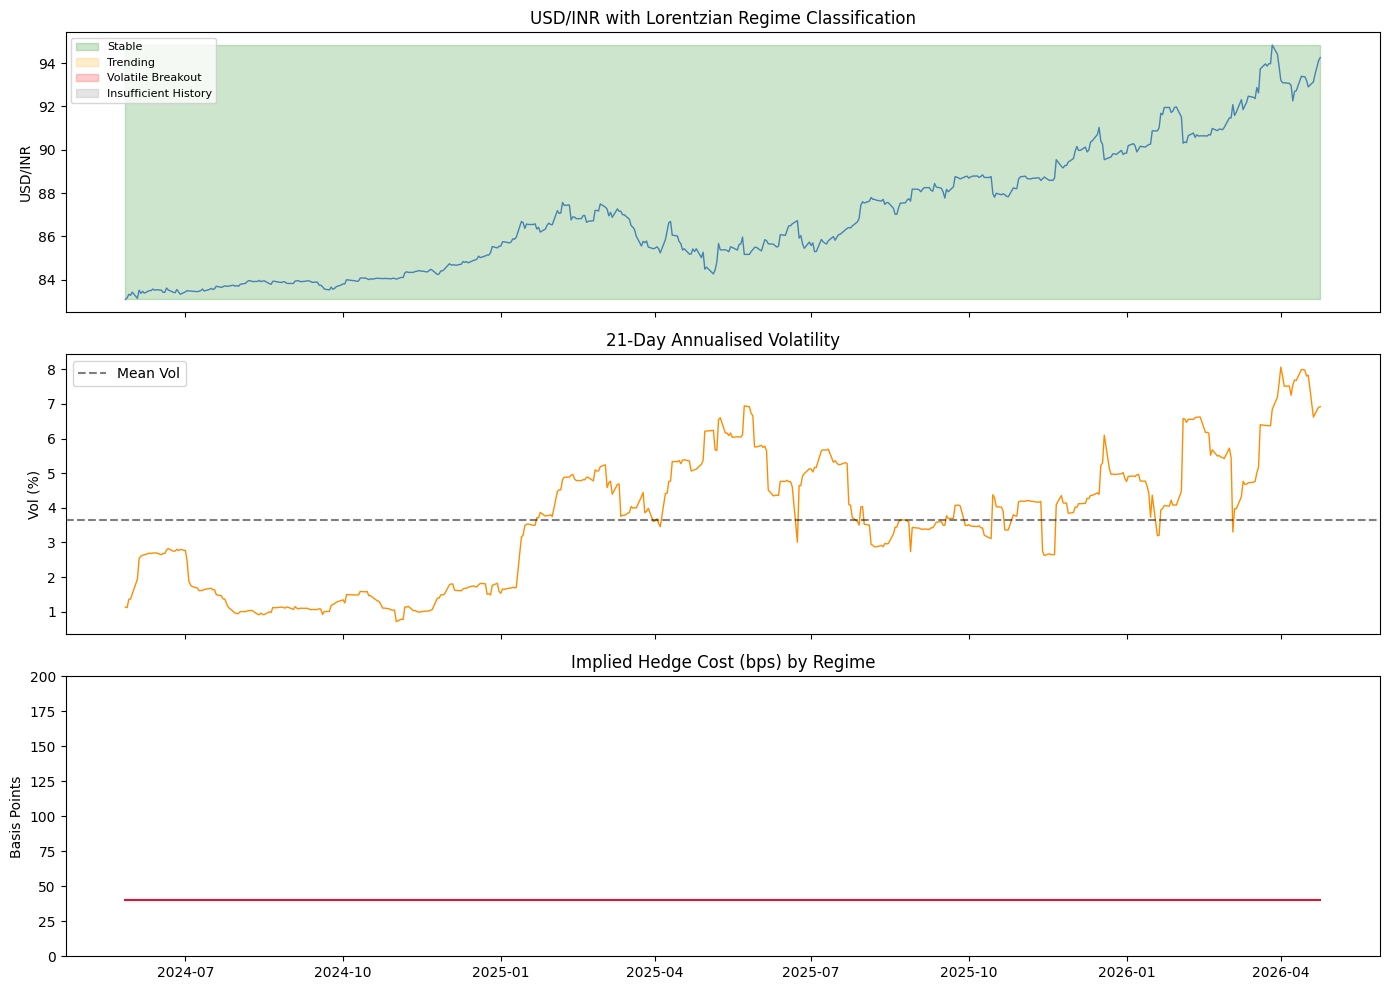


Saved fx_oracle.csv and fx_oracle.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load FX data ──────────────────────────────────────────────────────────────
fx = pd.read_csv('../data/DEXINUS.csv',
                 parse_dates=['observation_date'],
                 index_col='observation_date')
fx.columns = ['USDINR']
fx.replace('.', float('nan'), inplace=True)
fx = fx.astype(float)
fx = fx[fx.index >= '2005-01-01'].ffill()

# ── Feature Engineering ───────────────────────────────────────────────────────
fx['RETURNS']     = fx['USDINR'].pct_change()
fx['MA21']        = fx['USDINR'].rolling(21).mean()
fx['MA63']        = fx['USDINR'].rolling(63).mean()
fx['VOL21']       = fx['RETURNS'].rolling(21).std() * np.sqrt(252) * 100
fx['MOMENTUM21']  = fx['USDINR'].pct_change(21) * 100
fx['MOMENTUM63']  = fx['USDINR'].pct_change(63) * 100
fx['TREND']       = fx['MA21'] - fx['MA63']  # positive = rupee weakening trend

fx = fx.dropna()

# ── Lorentzian Distance KNN Classifier ───────────────────────────────────────
# Features we use to find similar historical periods
knn_features = ['VOL21', 'MOMENTUM21', 'MOMENTUM63', 'TREND']

# Normalize features to 0-1 range so no single feature dominates
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

fx_norm = fx[knn_features].apply(normalize)

def lorentzian_distance(a, b):
    """
    D_L = sum of ln(1 + |x_i - y_i|)
    Dampens the effect of extreme outliers compared to Euclidean distance.
    """
    return np.sum(np.log1p(np.abs(a - b)))

def classify_regime(row_idx, df_norm, k=21):
    """
    For a given row, find the k most similar historical days
    using Lorentzian distance, then vote on the regime.
    """
    current = df_norm.iloc[row_idx].values
    distances = []

    # Only look at history before this row (no lookahead)
    for j in range(max(0, row_idx - 252), row_idx):
        past = df_norm.iloc[j].values
        dist = lorentzian_distance(current, past)
        distances.append((dist, j))

    if len(distances) < k:
        return 'Insufficient History'

    # Get k nearest neighbors
    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]

    # Look at what happened to volatility 21 days after each neighbor
    vol_col = df_norm.columns.get_loc('VOL21')
    future_vols = []
    for _, j in neighbors:
        future_j = j + 21
        if future_j < len(df_norm):
            future_vols.append(df_norm.iloc[future_j, vol_col])

    if not future_vols:
        return 'Stable'

    avg_future_vol = np.mean(future_vols)

    # Classify based on predicted future volatility
    if avg_future_vol < 0.33:
        return 'Stable'
    elif avg_future_vol < 0.66:
        return 'Trending'
    else:
        return 'Volatile Breakout'

# ── Run classifier on recent 500 days (full run is slow) ─────────────────────
print("Running Lorentzian KNN classifier...")
print("This takes about 30-60 seconds...")

recent_n = 500
start_idx = len(fx) - recent_n

regimes = []
for i in range(start_idx, len(fx)):
    regime = classify_regime(i, fx_norm, k=21)
    regimes.append(regime)
    if (i - start_idx) % 100 == 0:
        print(f"  Progress: {i - start_idx}/{recent_n}")

fx_recent = fx.iloc[start_idx:].copy()
fx_recent['REGIME'] = regimes

print("Done.")

# ── Regime to Hedge Cost Mapping ──────────────────────────────────────────────
hedge_cost_map = {
    'Stable':           40,   # bps — vanilla forward hedge, low cost
    'Trending':         80,   # bps — directional options collar
    'Volatile Breakout':160,  # bps — protective options premium
    'Insufficient History': 80
}

fx_recent['HEDGE_COST_BPS'] = fx_recent['REGIME'].map(hedge_cost_map)

# ── Current reading ───────────────────────────────────────────────────────────
latest = fx_recent.iloc[-1]
print(f"\n{'='*50}")
print(f"  FX ORACLE — CURRENT READING")
print(f"{'='*50}")
print(f"  Date:         {fx_recent.index[-1].date()}")
print(f"  USD/INR:      {latest['USDINR']:.2f}")
print(f"  21D Vol:      {latest['VOL21']:.1f}%")
print(f"  21D Momentum: {latest['MOMENTUM21']:.2f}%")
print(f"  Regime:       {latest['REGIME']}")
print(f"  Hedge Cost:   {latest['HEDGE_COST_BPS']:.0f} bps")
print(f"{'='*50}")

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = {'Stable': 'green', 'Trending': 'orange',
          'Volatile Breakout': 'red', 'Insufficient History': 'gray'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# USD/INR with regime coloring
axes[0].plot(fx_recent.index, fx_recent['USDINR'], color='steelblue', linewidth=1)
for regime, color in colors.items():
    mask = fx_recent['REGIME'] == regime
    axes[0].fill_between(fx_recent.index, fx_recent['USDINR'].min(),
                         fx_recent['USDINR'].max(),
                         where=mask, alpha=0.2, color=color, label=regime)
axes[0].set_title('USD/INR with Lorentzian Regime Classification')
axes[0].set_ylabel('USD/INR')
axes[0].legend(loc='upper left', fontsize=8)

# Volatility
axes[1].plot(fx_recent.index, fx_recent['VOL21'],
             color='darkorange', linewidth=1)
axes[1].axhline(y=fx_recent['VOL21'].mean(), color='black',
                linestyle='--', alpha=0.5, label='Mean Vol')
axes[1].set_title('21-Day Annualised Volatility')
axes[1].set_ylabel('Vol (%)')
axes[1].legend()

# Hedge cost
axes[2].step(fx_recent.index, fx_recent['HEDGE_COST_BPS'],
             color='crimson', linewidth=1.5)
axes[2].set_title('Implied Hedge Cost (bps) by Regime')
axes[2].set_ylabel('Basis Points')
axes[2].set_ylim(0, 200)

plt.tight_layout()
plt.savefig('../data/fx_oracle.png', dpi=150)
plt.show()

# Save
fx_recent.to_csv('../data/fx_oracle.csv')
print("\nSaved fx_oracle.csv and fx_oracle.png")

Running classifier with rolling normalization...
  Progress: 0/500
  Progress: 100/500
  Progress: 200/500
  Progress: 300/500
  Progress: 400/500

Regime distribution:
REGIME
Trending             272
Stable               148
Volatile Breakout     80
Name: count, dtype: int64

  FX ORACLE — CURRENT READING
  Date:         2026-04-24
  USD/INR:      94.25
  21D Vol:      6.9%
  21D Momentum: 0.30%
  Regime:       Trending
  Hedge Cost:   80 bps


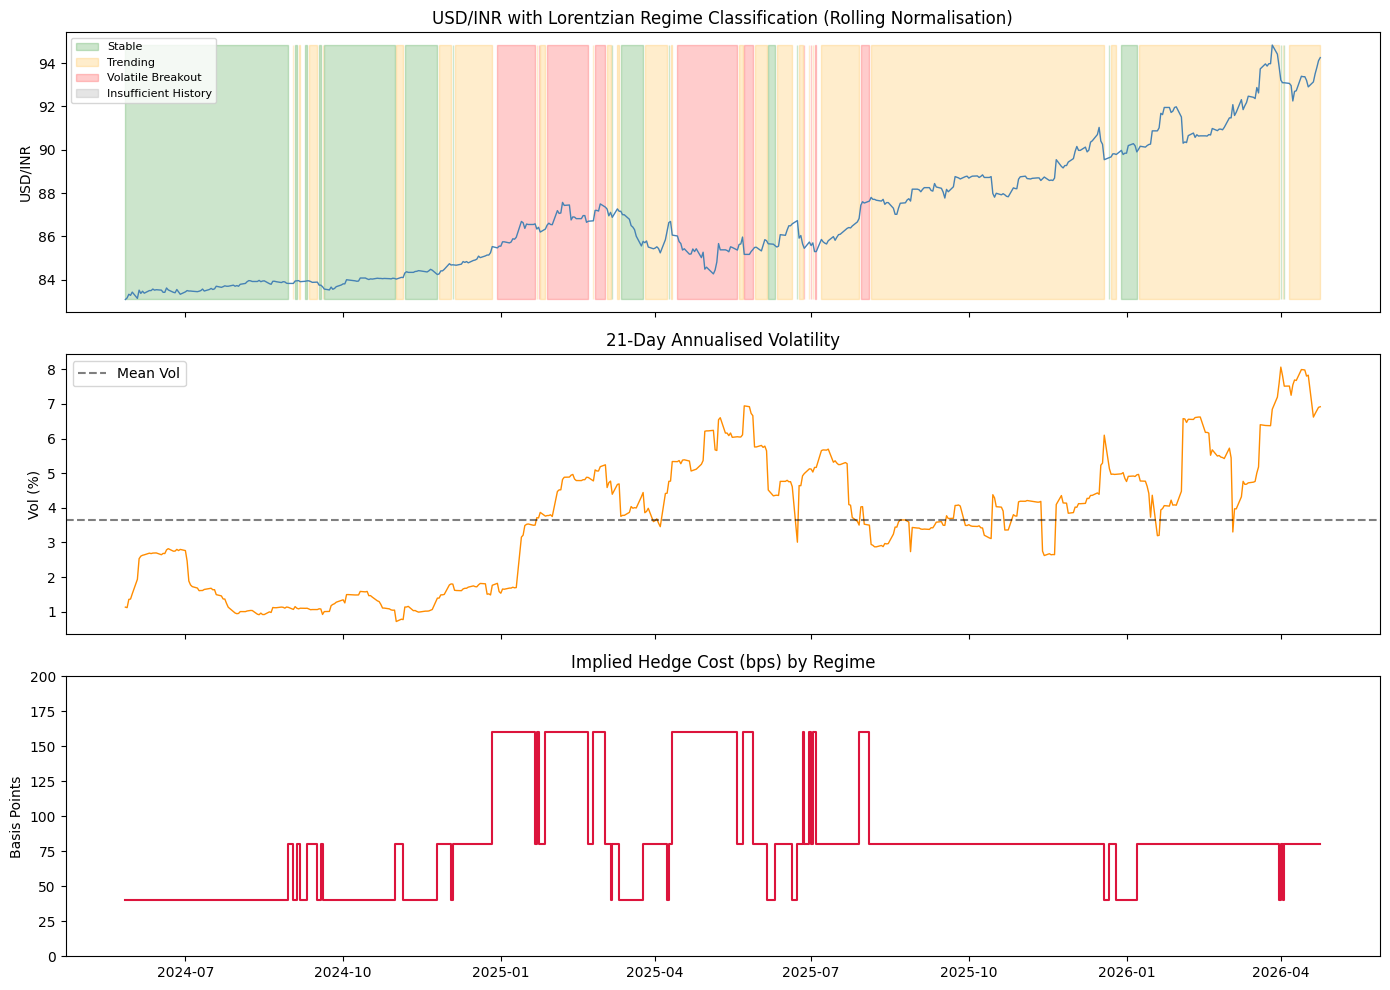


Saved.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fx = pd.read_csv('../data/DEXINUS.csv',
                 parse_dates=['observation_date'],
                 index_col='observation_date')
fx.columns = ['USDINR']
fx.replace('.', float('nan'), inplace=True)
fx = fx.astype(float)
fx = fx[fx.index >= '2005-01-01'].ffill()

fx['RETURNS']    = fx['USDINR'].pct_change()
fx['MA21']       = fx['USDINR'].rolling(21).mean()
fx['MA63']       = fx['USDINR'].rolling(63).mean()
fx['VOL21']      = fx['RETURNS'].rolling(21).std() * np.sqrt(252) * 100
fx['MOMENTUM21'] = fx['USDINR'].pct_change(21) * 100
fx['MOMENTUM63'] = fx['USDINR'].pct_change(63) * 100
fx['TREND']      = fx['MA21'] - fx['MA63']
fx = fx.dropna()

knn_features = ['VOL21', 'MOMENTUM21', 'MOMENTUM63', 'TREND']

# Rolling normalization — normalize against past 252 days only
# This makes the classifier sensitive to the CURRENT regime
# not the full 20-year history
def rolling_normalize(df, features, window=252):
    df_norm = df[features].copy()
    for col in features:
        rolling_min = df[col].rolling(window).min()
        rolling_max = df[col].rolling(window).max()
        denom = (rolling_max - rolling_min).replace(0, 1)
        df_norm[col] = (df[col] - rolling_min) / denom
    return df_norm.clip(0, 1)

fx_norm = rolling_normalize(fx, knn_features, window=252)

def lorentzian_distance(a, b):
    return np.sum(np.log1p(np.abs(a - b)))

def classify_regime(row_idx, df_norm, k=21):
    current = df_norm.iloc[row_idx].values
    distances = []
    for j in range(max(0, row_idx - 252), row_idx):
        past = df_norm.iloc[j].values
        if np.any(np.isnan(past)):
            continue
        dist = lorentzian_distance(current, past)
        distances.append((dist, j))

    if len(distances) < k:
        return 'Insufficient History'

    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]

    vol_col = df_norm.columns.get_loc('VOL21')
    future_vols = []
    for _, j in neighbors:
        future_j = j + 21
        if future_j < len(df_norm):
            fv = df_norm.iloc[future_j, vol_col]
            if not np.isnan(fv):
                future_vols.append(fv)

    if not future_vols:
        return 'Stable'

    avg_future_vol = np.mean(future_vols)

    if avg_future_vol < 0.40:
        return 'Stable'
    elif avg_future_vol < 0.70:
        return 'Trending'
    else:
        return 'Volatile Breakout'

print("Running classifier with rolling normalization...")
recent_n = 500
start_idx = len(fx) - recent_n

regimes = []
for i in range(start_idx, len(fx)):
    regime = classify_regime(i, fx_norm, k=21)
    regimes.append(regime)
    if (i - start_idx) % 100 == 0:
        print(f"  Progress: {i - start_idx}/{recent_n}")

fx_recent = fx.iloc[start_idx:].copy()
fx_recent['REGIME'] = regimes

hedge_cost_map = {
    'Stable':            40,
    'Trending':          80,
    'Volatile Breakout': 160,
    'Insufficient History': 80
}

fx_recent['HEDGE_COST_BPS'] = fx_recent['REGIME'].map(hedge_cost_map)

# Print regime distribution so we can see it's working
print("\nRegime distribution:")
print(fx_recent['REGIME'].value_counts())

latest = fx_recent.iloc[-1]
print(f"\n{'='*50}")
print(f"  FX ORACLE — CURRENT READING")
print(f"{'='*50}")
print(f"  Date:         {fx_recent.index[-1].date()}")
print(f"  USD/INR:      {latest['USDINR']:.2f}")
print(f"  21D Vol:      {latest['VOL21']:.1f}%")
print(f"  21D Momentum: {latest['MOMENTUM21']:.2f}%")
print(f"  Regime:       {latest['REGIME']}")
print(f"  Hedge Cost:   {latest['HEDGE_COST_BPS']:.0f} bps")
print(f"{'='*50}")

colors = {'Stable': 'green', 'Trending': 'orange',
          'Volatile Breakout': 'red', 'Insufficient History': 'gray'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(fx_recent.index, fx_recent['USDINR'], color='steelblue', linewidth=1)
for regime, color in colors.items():
    mask = fx_recent['REGIME'] == regime
    axes[0].fill_between(fx_recent.index, fx_recent['USDINR'].min(),
                         fx_recent['USDINR'].max(),
                         where=mask, alpha=0.2, color=color, label=regime)
axes[0].set_title('USD/INR with Lorentzian Regime Classification (Rolling Normalisation)')
axes[0].set_ylabel('USD/INR')
axes[0].legend(loc='upper left', fontsize=8)

axes[1].plot(fx_recent.index, fx_recent['VOL21'], color='darkorange', linewidth=1)
axes[1].axhline(y=fx_recent['VOL21'].mean(), color='black',
                linestyle='--', alpha=0.5, label='Mean Vol')
axes[1].set_title('21-Day Annualised Volatility')
axes[1].set_ylabel('Vol (%)')
axes[1].legend()

axes[2].step(fx_recent.index, fx_recent['HEDGE_COST_BPS'], color='crimson', linewidth=1.5)
axes[2].set_title('Implied Hedge Cost (bps) by Regime')
axes[2].set_ylabel('Basis Points')
axes[2].set_ylim(0, 200)

plt.tight_layout()
plt.savefig('../data/fx_oracle.png', dpi=150)
plt.show()

fx_recent.to_csv('../data/fx_oracle.csv')
print("\nSaved.")

In [20]:
import pandas as pd

fx_recent = pd.read_csv('../data/fx_oracle.csv',
                        parse_dates=['observation_date'],
                        index_col='observation_date')

print("Regime distribution:")
print(fx_recent['REGIME'].value_counts())
print(f"\nHedge cost distribution:")
print(fx_recent['HEDGE_COST_BPS'].value_counts())

Regime distribution:
REGIME
Trending             272
Stable               148
Volatile Breakout     80
Name: count, dtype: int64

Hedge cost distribution:
HEDGE_COST_BPS
80     272
40     148
160     80
Name: count, dtype: int64


In [21]:
import os

app_dir = '../app'
os.makedirs(app_dir, exist_ok=True)

app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="STF-Alpha-Pricer",
    page_icon="📊",
    layout="wide"
)

# ── Load data and model ───────────────────────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv('../data/fred_master.csv',
                     parse_dates=['date'], index_col='date')
    fx = pd.read_csv('../data/fx_oracle.csv',
                     parse_dates=['observation_date'],
                     index_col='observation_date')
    return df, fx

@st.cache_resource
def load_model():
    with open('../data/xgboost_model.pkl', 'rb') as f:
        return pickle.load(f)

df, fx = load_data()
model  = load_model()

features = [
    'SPREAD_LAG5', 'SPREAD_LAG21', 'SPREAD_LAG63',
    'SPREAD_VOL21', 'DXY_21D_CHG', 'DXY_63D_CHG',
    'VIX_21D_CHG', 'VIX_LEVEL', 'RATE_LEVEL',
    'RATE_21D_CHG', 'DBAA_LEVEL'
]

# ── Header ────────────────────────────────────────────────────────────────────
st.title("STF-Alpha-Pricer")
st.caption("Commodity Trade Finance Discount Rate Engine · Macro Risk + FX Hedge Cost")
st.divider()

# ── Sidebar inputs ────────────────────────────────────────────────────────────
st.sidebar.header("Deal Parameters")

invoice_value = st.sidebar.number_input(
    "Invoice Value (USD)",
    min_value=100_000,
    max_value=500_000_000,
    value=5_000_000,
    step=100_000,
    format="%d"
)

tenor_days = st.sidebar.selectbox(
    "Tenor (days)",
    options=[30, 60, 90, 120, 180],
    index=2
)

commodity = st.sidebar.selectbox(
    "Commodity",
    options=["Copper", "Iron Ore", "Crude Oil", "Aluminium", "Zinc"]
)

corridor = st.sidebar.selectbox(
    "Trade Corridor",
    options=["Asia → Europe", "Americas → Asia", "Africa → Asia",
             "Middle East → Asia", "Asia → Americas"]
)

profit_margin_bps = st.sidebar.slider(
    "Profit Margin (bps)",
    min_value=50,
    max_value=300,
    value=150,
    step=25
)

st.sidebar.divider()
st.sidebar.caption("Model: XGBoost macro risk engine + Lorentzian KNN FX oracle")

# ── Compute risk premium ──────────────────────────────────────────────────────
latest_features = df[features].dropna().iloc[-1]
latest_date     = df[features].dropna().index[-1]
predicted_spread_pct = model.predict(latest_features.values.reshape(1, -1))[0]
predicted_spread_bps = predicted_spread_pct * 100

base_rate = df["DGS3MO"].dropna().iloc[-1]

# FX hedge cost from oracle
fx_latest        = fx.iloc[-1]
fx_regime        = fx_latest["REGIME"]
fx_hedge_bps     = fx_latest["HEDGE_COST_BPS"]
usdinr_rate      = fx_latest["USDINR"]
fx_vol           = fx_latest["VOL21"]

# Commodity adjustment (basis points added to margin)
commodity_adj = {
    "Copper":     20,
    "Iron Ore":   10,
    "Crude Oil":  0,
    "Aluminium":  15,
    "Zinc":       25
}
commodity_bps = commodity_adj[commodity]

# Tenor adjustment (longer tenor = more risk)
tenor_adj_bps = int((tenor_days - 90) / 30 * 10)

total_bps = (base_rate * 100) + predicted_spread_bps + fx_hedge_bps + profit_margin_bps + commodity_bps + tenor_adj_bps
total_rate = total_bps / 100

# Finance cost on the invoice
finance_cost_usd = invoice_value * (total_rate / 100) * (tenor_days / 365)

# ── Regime badge ──────────────────────────────────────────────────────────────
regime_color = {
    "Stable":            "green",
    "Trending":          "orange",
    "Volatile Breakout": "red",
    "Insufficient History": "gray"
}
badge = regime_color.get(fx_regime, "gray")

# ── Main output ───────────────────────────────────────────────────────────────
col1, col2, col3, col4 = st.columns(4)

col1.metric("Indicative Rate", f"{total_rate:.2f}%",
            help="All-in discount rate for the deal")
col2.metric("Finance Cost",    f"${finance_cost_usd:,.0f}",
            help=f"Cost of financing over {tenor_days} days")
col3.metric("Risk Premium",    f"{predicted_spread_bps:.0f} bps",
            help="XGBoost macro stress prediction")
col4.metric("FX Hedge Cost",   f"{fx_hedge_bps:.0f} bps",
            help=f"Regime: {fx_regime}")

st.divider()

# ── Rate breakdown ────────────────────────────────────────────────────────────
st.subheader("Rate Breakdown")

components = {
    f"Base Rate (3M T-Bill)":          base_rate * 100,
    f"Macro Risk Premium (XGBoost)":   predicted_spread_bps,
    f"FX Hedge Cost ({fx_regime})":    fx_hedge_bps,
    f"Commodity Adj ({commodity})":    commodity_bps,
    f"Tenor Adj ({tenor_days}d)":      tenor_adj_bps,
    f"Profit Margin":                  profit_margin_bps,
}

fig, ax = plt.subplots(figsize=(10, 3))
colors_bar = ["#2196F3", "#E53935", "#FF9800", "#9C27B0", "#607D8B", "#4CAF50"]
bars = ax.barh(list(components.keys()), list(components.values()),
               color=colors_bar, height=0.5)
ax.set_xlabel("Basis Points")
ax.set_title(f"All-in Rate: {total_rate:.2f}%  ({total_bps:.0f} bps)")
for bar, val in zip(bars, components.values()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.0f} bps", va="center", fontsize=9)
ax.set_xlim(0, max(components.values()) * 1.3)
plt.tight_layout()
st.pyplot(fig)
plt.close()

st.divider()

# ── Market context ────────────────────────────────────────────────────────────
st.subheader("Market Context")

col_a, col_b = st.columns(2)

with col_a:
    st.markdown("**Macro Stress Indicators**")
    current_spread = df["CREDIT_SPREAD"].dropna().iloc[-1]
    hist_mean      = 3.62
    st.write(f"Credit spread today: **{current_spread:.2f}%** (hist. mean: {hist_mean:.2f}%)")
    st.write(f"VIX: **{df['VIXCLS'].dropna().iloc[-1]:.1f}**")
    st.write(f"DXY: **{df['DTWEXBGS'].dropna().iloc[-1]:.1f}**")
    stress = "🔴 ELEVATED" if predicted_spread_pct > hist_mean else "🟡 MODERATE" if predicted_spread_pct > hist_mean * 0.75 else "🟢 LOW"
    st.write(f"Model stress signal: **{stress}**")

with col_b:
    st.markdown("**FX Oracle — USD/INR**")
    st.write(f"Spot rate: **{usdinr_rate:.2f}**")
    st.write(f"21D Annualised Vol: **{fx_vol:.1f}%**")
    regime_display = f":{badge}[**{fx_regime}**]"
    st.write(f"Regime: {regime_display}")
    st.write(f"Implied hedge cost: **{fx_hedge_bps} bps**")

st.divider()
st.caption(f"Data as of {latest_date.date()} · Model trained on 2006–2019 · Walk-forward tested 2019–2025")
'''

with open(f'{app_dir}/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("App file written to ../app/app.py")
print("To launch, open a terminal and run:")
print("  cd app")
print("  streamlit run app.py")

App file written to ../app/app.py
To launch, open a terminal and run:
  cd app
  streamlit run app.py


In [22]:
import pandas as pd
import os

files = [
    'PCOPPUSDM.csv', 'PIORECRUSDM.csv', 'POILBREUSDM.csv',
    'PALUMUSDM.csv', 'PZINCUSDM.csv',
    'DEXUSEU.csv', 'DEXCHUS.csv', 'DEXSFUS.csv', 'DEXMXUS.csv'
]

for filename in files:
    path = f'../data/{filename}'
    df_temp = pd.read_csv(path, nrows=3)
    code = filename.replace('.csv', '')
    print(f"{code}: columns = {df_temp.columns.tolist()}")

PCOPPUSDM: columns = ['observation_date', 'PCOPPUSDM']
PIORECRUSDM: columns = ['observation_date', 'PIORECRUSDM']
POILBREUSDM: columns = ['observation_date', 'POILBREUSDM']
PALUMUSDM: columns = ['observation_date', 'PALUMUSDM']
PZINCUSDM: columns = ['observation_date', 'PZINCUSDM']
DEXUSEU: columns = ['observation_date', 'DEXUSEU']
DEXCHUS: columns = ['observation_date', 'DEXCHUS']
DEXSFUS: columns = ['observation_date', 'DEXSFUS']
DEXMXUS: columns = ['observation_date', 'DEXMXUS']


In [23]:
import pandas as pd
import numpy as np
import pickle
import os

# ── Step 1: Commodity volatility adjustment ───────────────────────────────────
print("Computing commodity volatility adjustments...")

commodity_files = {
    'Copper':    'PCOPPUSDM',
    'Iron Ore':  'PIORECRUSDM',
    'Crude Oil': 'POILBREUSDM',
    'Aluminium': 'PALUMUSDM',
    'Zinc':      'PZINCUSDM',
}

commodity_vol = {}
for name, code in commodity_files.items():
    df_c = pd.read_csv(f'../data/{code}.csv',
                       parse_dates=['observation_date'],
                       index_col='observation_date')
    df_c.columns = [code]
    df_c.replace('.', float('nan'), inplace=True)
    df_c = df_c.astype(float).dropna()
    # 3-year rolling annualised volatility of monthly returns
    returns = df_c[code].pct_change()
    vol_3yr = returns.rolling(36).std().iloc[-1] * np.sqrt(12) * 100
    commodity_vol[name] = vol_3yr
    print(f"  {name}: 3Y annualised vol = {vol_3yr:.1f}%")

# Scale vol to basis points adjustment (range: 0 to 60 bps)
min_vol = min(commodity_vol.values())
max_vol = max(commodity_vol.values())
commodity_adj_bps = {
    name: int(((vol - min_vol) / (max_vol - min_vol)) * 60)
    for name, vol in commodity_vol.items()
}

print("\nCommodity adjustments (data-driven):")
for name, bps in commodity_adj_bps.items():
    print(f"  {name}: {bps} bps  (vol={commodity_vol[name]:.1f}%)")

# Save for app to load
pd.DataFrame({
    'commodity': list(commodity_adj_bps.keys()),
    'vol_pct':   [commodity_vol[c] for c in commodity_adj_bps],
    'adj_bps':   list(commodity_adj_bps.values())
}).to_csv('../data/commodity_adj.csv', index=False)
print("\nSaved commodity_adj.csv")

# ── Step 2: Multi-corridor FX oracle ─────────────────────────────────────────
print("\nBuilding multi-corridor FX oracle...")

corridor_fx = {
    'Asia → Europe':      ('DEXINUS',  'USD/INR'),
    'Americas → Asia':    ('DEXCHUS',  'USD/CNY'),
    'Africa → Asia':      ('DEXSFUS',  'USD/ZAR'),
    'Middle East → Asia': ('DEXINUS',  'USD/INR'),
    'Asia → Americas':    ('DEXMXUS',  'USD/MXN'),
}

# Load all FX series
fx_series = {}
for code in ['DEXINUS', 'DEXCHUS', 'DEXSFUS', 'DEXMXUS', 'DEXUSEU']:
    path = f'../data/{code}.csv'
    df_fx = pd.read_csv(path, parse_dates=['observation_date'],
                        index_col='observation_date')
    df_fx.columns = [code]
    df_fx.replace('.', float('nan'), inplace=True)
    df_fx = df_fx.astype(float)
    df_fx = df_fx[df_fx.index >= '2005-01-01'].ffill()
    fx_series[code] = df_fx
    print(f"  {code}: {len(df_fx)} rows, latest = {df_fx.iloc[-1,0]:.4f}")

def compute_fx_features(df_fx, code):
    fx = df_fx.copy()
    fx['RETURNS']    = fx[code].pct_change()
    fx['MA21']       = fx[code].rolling(21).mean()
    fx['MA63']       = fx[code].rolling(63).mean()
    fx['VOL21']      = fx['RETURNS'].rolling(21).std() * np.sqrt(252) * 100
    fx['MOMENTUM21'] = fx[code].pct_change(21) * 100
    fx['MOMENTUM63'] = fx[code].pct_change(63) * 100
    fx['TREND']      = fx['MA21'] - fx['MA63']
    return fx.dropna()

def rolling_normalize(df, features, window=252):
    df_norm = df[features].copy()
    for col in features:
        rolling_min = df[col].rolling(window).min()
        rolling_max = df[col].rolling(window).max()
        denom = (rolling_max - rolling_min).replace(0, 1)
        df_norm[col] = (df[col] - rolling_min) / denom
    return df_norm.clip(0, 1)

def lorentzian_distance(a, b):
    return np.sum(np.log1p(np.abs(a - b)))

def classify_regime(row_idx, df_norm, k=21):
    current = df_norm.iloc[row_idx].values
    distances = []
    for j in range(max(0, row_idx - 252), row_idx):
        past = df_norm.iloc[j].values
        if np.any(np.isnan(past)):
            continue
        distances.append((lorentzian_distance(current, past), j))
    if len(distances) < k:
        return 'Insufficient History'
    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]
    vol_col = df_norm.columns.get_loc('VOL21')
    future_vols = []
    for _, j in neighbors:
        future_j = j + 21
        if future_j < len(df_norm):
            fv = df_norm.iloc[future_j, vol_col]
            if not np.isnan(fv):
                future_vols.append(fv)
    if not future_vols:
        return 'Stable'
    avg = np.mean(future_vols)
    if avg < 0.40:   return 'Stable'
    elif avg < 0.70: return 'Trending'
    else:            return 'Volatile Breakout'

hedge_cost_map = {
    'Stable': 40, 'Trending': 80,
    'Volatile Breakout': 160, 'Insufficient History': 80
}

knn_features = ['VOL21', 'MOMENTUM21', 'MOMENTUM63', 'TREND']

# Run classifier for each unique FX pair
fx_results = {}
unique_codes = list(set(v[0] for v in corridor_fx.values()))

for code in unique_codes:
    print(f"  Classifying {code}...")
    fx = compute_fx_features(fx_series[code], code)
    fx_norm = rolling_normalize(fx, knn_features)
    recent_n  = 500
    start_idx = len(fx) - recent_n
    regimes = []
    for i in range(start_idx, len(fx)):
        regimes.append(classify_regime(i, fx_norm, k=21))
    fx_recent = fx.iloc[start_idx:].copy()
    fx_recent['REGIME']         = regimes
    fx_recent['HEDGE_COST_BPS'] = fx_recent['REGIME'].map(hedge_cost_map)
    fx_recent['FX_CODE']        = code
    fx_results[code] = fx_recent
    latest = fx_recent.iloc[-1]
    print(f"    Latest: {fx_recent.index[-1].date()} | "
          f"Rate={fx_series[code].iloc[-1,0]:.4f} | "
          f"Vol={latest['VOL21']:.1f}% | "
          f"Regime={latest['REGIME']} | "
          f"Hedge={latest['HEDGE_COST_BPS']} bps")

# Save combined oracle
fx_all = pd.concat(fx_results.values())
fx_all.to_csv('../data/fx_oracle_multi.csv')
print("\nSaved fx_oracle_multi.csv")

# Save corridor mapping
corridor_map = pd.DataFrame([
    {'corridor': k, 'fx_code': v[0], 'fx_pair': v[1]}
    for k, v in corridor_fx.items()
])
corridor_map.to_csv('../data/corridor_map.csv', index=False)
print("Saved corridor_map.csv")
print("\nAll data ready. Writing app...")

Computing commodity volatility adjustments...
  Copper: 3Y annualised vol = 14.8%
  Iron Ore: 3Y annualised vol = 20.4%
  Crude Oil: 3Y annualised vol = 30.9%
  Aluminium: 3Y annualised vol = 14.6%
  Zinc: 3Y annualised vol = 17.4%

Commodity adjustments (data-driven):
  Copper: 0 bps  (vol=14.8%)
  Iron Ore: 21 bps  (vol=20.4%)
  Crude Oil: 60 bps  (vol=30.9%)
  Aluminium: 0 bps  (vol=14.6%)
  Zinc: 10 bps  (vol=17.4%)

Saved commodity_adj.csv

Building multi-corridor FX oracle...
  DEXINUS: 5560 rows, latest = 94.2500
  DEXCHUS: 5560 rows, latest = 6.8359
  DEXSFUS: 5560 rows, latest = 16.4929
  DEXMXUS: 5560 rows, latest = 17.3853
  DEXUSEU: 5560 rows, latest = 1.1718
  Classifying DEXCHUS...
    Latest: 2026-04-24 | Rate=6.8359 | Vol=2.6% | Regime=Stable | Hedge=40 bps
  Classifying DEXINUS...
    Latest: 2026-04-24 | Rate=94.2500 | Vol=6.9% | Regime=Trending | Hedge=80 bps
  Classifying DEXMXUS...
    Latest: 2026-04-24 | Rate=17.3853 | Vol=10.8% | Regime=Trending | Hedge=80 bps
 

In [24]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

st.set_page_config(
    page_title="STF-Alpha-Pricer",
    page_icon="📊",
    layout="wide"
)

# ── Load all data ─────────────────────────────────────────────────────────────
@st.cache_data
def load_all():
    df = pd.read_csv('../data/fred_master.csv',
                     parse_dates=['date'], index_col='date')
    fx_multi = pd.read_csv('../data/fx_oracle_multi.csv',
                           parse_dates=['observation_date'],
                           index_col='observation_date')
    commodity_adj = pd.read_csv('../data/commodity_adj.csv',
                                index_col='commodity')
    corridor_map = pd.read_csv('../data/corridor_map.csv',
                               index_col='corridor')
    return df, fx_multi, commodity_adj, corridor_map

@st.cache_resource
def load_model():
    with open('../data/xgboost_model.pkl', 'rb') as f:
        return pickle.load(f)

df, fx_multi, commodity_adj, corridor_map = load_all()
model = load_model()

features = [
    'SPREAD_LAG5', 'SPREAD_LAG21', 'SPREAD_LAG63',
    'SPREAD_VOL21', 'DXY_21D_CHG', 'DXY_63D_CHG',
    'VIX_21D_CHG', 'VIX_LEVEL', 'RATE_LEVEL',
    'RATE_21D_CHG', 'DBAA_LEVEL'
]

# ── Sidebar ───────────────────────────────────────────────────────────────────
st.sidebar.header("Deal Parameters")

invoice_value = st.sidebar.number_input(
    "Invoice Value (USD)",
    min_value=100_000, max_value=500_000_000,
    value=5_000_000, step=100_000, format="%d"
)

tenor_days = st.sidebar.selectbox(
    "Tenor (days)", options=[30, 60, 90, 120, 180], index=2
)

commodity = st.sidebar.selectbox(
    "Commodity",
    options=["Copper", "Iron Ore", "Crude Oil", "Aluminium", "Zinc"]
)

corridor = st.sidebar.selectbox(
    "Trade Corridor",
    options=[
        "Asia → Europe",
        "Americas → Asia",
        "Africa → Asia",
        "Middle East → Asia",
        "Asia → Americas"
    ]
)

profit_margin_bps = st.sidebar.slider(
    "Profit Margin (bps)", min_value=50, max_value=300, value=150, step=25
)

st.sidebar.divider()
st.sidebar.markdown("**Model**")
st.sidebar.caption("Macro risk: XGBoost trained 2006-2019")
st.sidebar.caption("FX regime: Lorentzian KNN, k=21, 252-day rolling window")
st.sidebar.caption("Commodity adj: IMF 3Y annualised price volatility")

# ── Compute all components ────────────────────────────────────────────────────

# 1. Base rate
base_rate     = df['DGS3MO'].dropna().iloc[-1]
base_rate_bps = base_rate * 100

# 2. Macro risk premium from XGBoost
latest_features      = df[features].dropna().iloc[-1]
latest_date          = df[features].dropna().index[-1]
predicted_spread_pct = float(model.predict(
    latest_features.values.reshape(1, -1))[0])
risk_premium_bps     = predicted_spread_pct * 100

# 3. FX hedge cost from corridor
fx_code      = corridor_map.loc[corridor, 'fx_code']
fx_pair_name = corridor_map.loc[corridor, 'fx_pair']
fx_corridor  = fx_multi[fx_multi['FX_CODE'] == fx_code]
fx_latest    = fx_corridor.iloc[-1]
fx_regime    = fx_latest['REGIME']
fx_hedge_bps = float(fx_latest['HEDGE_COST_BPS'])
fx_spot      = fx_latest[fx_code]
fx_vol       = float(fx_latest['VOL21'])

# 4. Commodity adjustment from IMF vol
comm_bps     = int(commodity_adj.loc[commodity, 'adj_bps'])
comm_vol     = float(commodity_adj.loc[commodity, 'vol_pct'])

# 5. Tenor adjustment
tenor_adj_bps = int((tenor_days - 90) / 30 * 10)

# 6. Total
total_bps  = (base_rate_bps + risk_premium_bps + fx_hedge_bps +
              comm_bps + tenor_adj_bps + profit_margin_bps)
total_rate = total_bps / 100
finance_cost_usd = invoice_value * (total_rate / 100) * (tenor_days / 365)

# ── Header ────────────────────────────────────────────────────────────────────
st.title("STF-Alpha-Pricer")
st.caption(
    "Commodity Trade Finance Discount Rate Engine  ·  "
    "XGBoost Macro Risk  +  Lorentzian FX Oracle  +  IMF Commodity Volatility"
)
st.divider()

# ── Top metrics ───────────────────────────────────────────────────────────────
c1, c2, c3, c4, c5 = st.columns(5)
c1.metric("All-in Rate",     f"{total_rate:.2f}%")
c2.metric("Finance Cost",    f"${finance_cost_usd:,.0f}")
c3.metric("Risk Premium",    f"{risk_premium_bps:.0f} bps")
c4.metric("FX Hedge Cost",   f"{fx_hedge_bps:.0f} bps",
          help=f"{fx_pair_name} · {fx_regime}")
c5.metric("Commodity Adj",   f"{comm_bps} bps",
          help=f"{commodity} 3Y vol: {comm_vol:.1f}%")

st.divider()

# ── Waterfall chart ───────────────────────────────────────────────────────────
st.subheader("Rate Breakdown")

components = [
    ("Base Rate\n(3M T-Bill)",          base_rate_bps),
    (f"Macro Risk\n(XGBoost)",          risk_premium_bps),
    (f"FX Hedge\n({fx_pair_name})",     fx_hedge_bps),
    (f"Commodity\n({commodity})",        comm_bps),
    (f"Tenor\n({tenor_days}d)",         tenor_adj_bps),
    (f"Profit\nMargin",                  profit_margin_bps),
]

labels   = [c[0] for c in components]
values   = [c[1] for c in components]
bottoms  = []
running  = 0
for v in values:
    bottoms.append(running)
    running += v

bar_colors = [
    "#3B82F6",   # blue    — base rate
    "#EF4444",   # red     — macro risk
    "#F97316",   # orange  — FX hedge
    "#A855F7",   # purple  — commodity
    "#6B7280",   # gray    — tenor
    "#22C55E",   # green   — margin
]

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor("#0E1117")
ax.set_facecolor("#0E1117")

bar_width = 0.5
for i, (label, value, bottom, color) in enumerate(
        zip(labels, values, bottoms, bar_colors)):
    ax.bar(i, value, bottom=bottom, color=color,
           width=bar_width, zorder=3, alpha=0.92)
    # Value label inside bar
    ax.text(i, bottom + value / 2, f"{value:.0f}",
            ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')
    # Connector line to next bar
    if i < len(values) - 1:
        ax.plot([i + bar_width/2, i + 1 - bar_width/2],
                [bottom + value, bottom + value],
                color='#4B5563', linewidth=1, linestyle='--', zorder=2)

# Total bar
total_x = len(components)
ax.bar(total_x, total_bps, color='#F59E0B',
       width=bar_width, zorder=3, alpha=0.95)
ax.text(total_x, total_bps / 2, f"{total_bps:.0f}",
        ha='center', va='center',
        color='white', fontsize=10, fontweight='bold')
labels.append(f"All-in\nRate")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, color='#9CA3AF', fontsize=9)
ax.set_ylabel("Basis Points", color='#9CA3AF', fontsize=9)
ax.set_ylim(0, total_bps * 1.15)
ax.tick_params(colors='#9CA3AF')
ax.spines['bottom'].set_color('#374151')
ax.spines['left'].set_color('#374151')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#1F2937', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_title(
    f"All-in Rate: {total_rate:.2f}%  ({total_bps:.0f} bps)",
    color='white', fontsize=12, pad=12
)

plt.tight_layout()
st.pyplot(fig)
plt.close()

st.divider()

# ── Market context ────────────────────────────────────────────────────────────
st.subheader("Market Context")

col_a, col_b, col_c = st.columns(3)

with col_a:
    st.markdown("**Macro Stress**")
    current_spread = df['CREDIT_SPREAD'].dropna().iloc[-1]
    hist_mean      = 3.62
    stress_label   = (
        "ELEVATED" if predicted_spread_pct > hist_mean
        else "MODERATE" if predicted_spread_pct > hist_mean * 0.75
        else "LOW"
    )
    stress_color = (
        "red" if stress_label == "ELEVATED"
        else "orange" if stress_label == "MODERATE"
        else "green"
    )
    st.write(f"Model signal: :{stress_color}[**{stress_label}**]")
    st.write(f"Predicted spread: **{predicted_spread_pct:.2f}%**")
    st.write(f"Historical mean: **{hist_mean:.2f}%**")
    st.write(f"VIX: **{df['VIXCLS'].dropna().iloc[-1]:.1f}**")
    st.write(f"DXY: **{df['DTWEXBGS'].dropna().iloc[-1]:.1f}**")
    st.caption(f"As of {latest_date.date()}")

with col_b:
    st.markdown(f"**FX Oracle — {fx_pair_name}**")
    regime_color = {
        "Stable": "green",
        "Trending": "orange",
        "Volatile Breakout": "red",
        "Insufficient History": "gray"
    }.get(fx_regime, "gray")
    st.write(f"Corridor: **{corridor}**")
    st.write(f"Spot: **{fx_spot:.4f}**")
    st.write(f"21D Vol: **{fx_vol:.1f}%**")
    st.write(f"Regime: :{regime_color}[**{fx_regime}**]")
    st.write(f"Hedge cost: **{fx_hedge_bps:.0f} bps**")
    st.caption("Lorentzian KNN, k=21, 252-day rolling window")

with col_c:
    st.markdown(f"**Commodity — {commodity}**")
    st.write(f"3Y annualised vol: **{comm_vol:.1f}%**")
    st.write(f"Vol-based adjustment: **{comm_bps} bps**")
    st.divider()
    st.markdown("**Deal Summary**")
    st.write(f"Invoice: **${invoice_value:,.0f}**")
    st.write(f"Tenor: **{tenor_days} days**")
    st.write(f"Finance cost: **${finance_cost_usd:,.0f}**")
    st.caption("IMF Global Commodity Price series via FRED")

st.divider()
st.caption(
    f"Data: FRED · IMF · RBI  |  "
    f"Macro model trained 2006-2019, walk-forward tested 2019-2025  |  "
    f"MAE 0.62%  R² 0.66  |  "
    f"As of {latest_date.date()}"
)
'''

import os
os.makedirs('../app', exist_ok=True)
with open('../app/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("App written. Restart your Streamlit server:")
print("  Ctrl+C in the terminal running streamlit")
print("  Then: streamlit run app.py")

App written. Restart your Streamlit server:
  Ctrl+C in the terminal running streamlit
  Then: streamlit run app.py


In [25]:
import os

os.makedirs('../app', exist_ok=True)

lines = [
    "import streamlit as st",
    "import pandas as pd",
    "import numpy as np",
    "import pickle",
    "import matplotlib.pyplot as plt",
    "",
    "st.set_page_config(page_title='STF-Alpha-Pricer', page_icon='📊', layout='wide')",
    "",
    "@st.cache_data",
    "def load_all():",
    "    df = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')",
    "    fx_multi = pd.read_csv('../data/fx_oracle_multi.csv', parse_dates=['observation_date'], index_col='observation_date')",
    "    commodity_adj = pd.read_csv('../data/commodity_adj.csv', index_col='commodity')",
    "    corridor_map = pd.read_csv('../data/corridor_map.csv', index_col='corridor')",
    "    return df, fx_multi, commodity_adj, corridor_map",
    "",
    "@st.cache_resource",
    "def load_model():",
    "    with open('../data/xgboost_model.pkl', 'rb') as f:",
    "        return pickle.load(f)",
    "",
    "df, fx_multi, commodity_adj, corridor_map = load_all()",
    "model = load_model()",
    "",
    "features = ['SPREAD_LAG5','SPREAD_LAG21','SPREAD_LAG63','SPREAD_VOL21',",
    "            'DXY_21D_CHG','DXY_63D_CHG','VIX_21D_CHG','VIX_LEVEL',",
    "            'RATE_LEVEL','RATE_21D_CHG','DBAA_LEVEL']",
    "",
    "st.sidebar.header('Deal Parameters')",
    "invoice_value = st.sidebar.number_input('Invoice Value (USD)', min_value=100000, max_value=500000000, value=5000000, step=100000, format='%d')",
    "tenor_days = st.sidebar.selectbox('Tenor (days)', options=[30,60,90,120,180], index=2)",
    "commodity = st.sidebar.selectbox('Commodity', options=['Copper','Iron Ore','Crude Oil','Aluminium','Zinc'])",
    "corridor = st.sidebar.selectbox('Trade Corridor', options=['Asia to Europe','Americas to Asia','Africa to Asia','Middle East to Asia','Asia to Americas'])",
    "profit_margin_bps = st.sidebar.slider('Profit Margin (bps)', min_value=50, max_value=300, value=150, step=25)",
    "st.sidebar.divider()",
    "st.sidebar.caption('Macro risk: XGBoost trained 2006-2019')",
    "st.sidebar.caption('FX regime: Lorentzian KNN, k=21, 252-day rolling window')",
    "st.sidebar.caption('Commodity adj: IMF 3Y annualised price volatility')",
    "",
    "base_rate = df['DGS3MO'].dropna().iloc[-1]",
    "base_rate_bps = base_rate * 100",
    "",
    "latest_features = df[features].dropna().iloc[-1]",
    "latest_date = df[features].dropna().index[-1]",
    "predicted_spread_pct = float(model.predict(latest_features.values.reshape(1,-1))[0])",
    "risk_premium_bps = predicted_spread_pct * 100",
    "",
    "fx_code = corridor_map.loc[corridor, 'fx_code']",
    "fx_pair_name = corridor_map.loc[corridor, 'fx_pair']",
    "fx_corridor = fx_multi[fx_multi['FX_CODE'] == fx_code]",
    "fx_latest = fx_corridor.iloc[-1]",
    "fx_regime = fx_latest['REGIME']",
    "fx_hedge_bps = float(fx_latest['HEDGE_COST_BPS'])",
    "fx_spot = fx_latest[fx_code]",
    "fx_vol = float(fx_latest['VOL21'])",
    "",
    "comm_bps = int(commodity_adj.loc[commodity, 'adj_bps'])",
    "comm_vol = float(commodity_adj.loc[commodity, 'vol_pct'])",
    "",
    "tenor_adj_bps = int((tenor_days - 90) / 30 * 10)",
    "",
    "total_bps = base_rate_bps + risk_premium_bps + fx_hedge_bps + comm_bps + tenor_adj_bps + profit_margin_bps",
    "total_rate = total_bps / 100",
    "finance_cost_usd = invoice_value * (total_rate / 100) * (tenor_days / 365)",
    "",
    "st.title('STF-Alpha-Pricer')",
    "st.caption('Commodity Trade Finance Discount Rate Engine  |  XGBoost Macro Risk  +  Lorentzian FX Oracle  +  IMF Commodity Volatility')",
    "st.divider()",
    "",
    "c1,c2,c3,c4,c5 = st.columns(5)",
    "c1.metric('All-in Rate', f'{total_rate:.2f}%')",
    "c2.metric('Finance Cost', f'${finance_cost_usd:,.0f}')",
    "c3.metric('Risk Premium', f'{risk_premium_bps:.0f} bps')",
    "c4.metric('FX Hedge Cost', f'{fx_hedge_bps:.0f} bps', help=f'{fx_pair_name} - {fx_regime}')",
    "c5.metric('Commodity Adj', f'{comm_bps} bps', help=f'{commodity} 3Y vol: {comm_vol:.1f}%')",
    "st.divider()",
    "",
    "st.subheader('Rate Breakdown')",
    "",
    "comp_labels = ['Base Rate (3M T-Bill)', 'Macro Risk (XGBoost)', f'FX Hedge ({fx_pair_name})', f'Commodity ({commodity})', f'Tenor ({tenor_days}d)', 'Profit Margin', 'All-in Rate']",
    "comp_values = [base_rate_bps, risk_premium_bps, fx_hedge_bps, comm_bps, tenor_adj_bps, profit_margin_bps, total_bps]",
    "",
    "bottoms = []",
    "running = 0",
    "for v in comp_values[:-1]:",
    "    bottoms.append(running)",
    "    running += v",
    "",
    "bar_colors = ['#3B82F6','#EF4444','#F97316','#A855F7','#6B7280','#22C55E','#F59E0B']",
    "",
    "fig, ax = plt.subplots(figsize=(12,4))",
    "fig.patch.set_facecolor('#0E1117')",
    "ax.set_facecolor('#0E1117')",
    "",
    "for i,(val,bot,col) in enumerate(zip(comp_values[:-1], bottoms, bar_colors[:-1])):",
    "    ax.bar(i, val, bottom=bot, color=col, width=0.5, zorder=3, alpha=0.92)",
    "    ax.text(i, bot+val/2, f'{val:.0f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold')",
    "    if i < len(comp_values)-2:",
    "        ax.plot([i+0.25, i+0.75], [bot+val, bot+val], color='#4B5563', linewidth=1, linestyle='--', zorder=2)",
    "",
    "ax.bar(len(comp_values)-1, total_bps, color='#F59E0B', width=0.5, zorder=3, alpha=0.95)",
    "ax.text(len(comp_values)-1, total_bps/2, f'{total_bps:.0f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold')",
    "",
    "ax.set_xticks(range(len(comp_labels)))",
    "ax.set_xticklabels(comp_labels, color='#9CA3AF', fontsize=8.5)",
    "ax.set_ylabel('Basis Points', color='#9CA3AF', fontsize=9)",
    "ax.set_ylim(0, total_bps*1.15)",
    "ax.tick_params(colors='#9CA3AF')",
    "for spine in ['bottom','left']: ax.spines[spine].set_color('#374151')",
    "for spine in ['top','right']: ax.spines[spine].set_visible(False)",
    "ax.yaxis.grid(True, color='#1F2937', linewidth=0.8, zorder=0)",
    "ax.set_axisbelow(True)",
    "ax.set_title(f'All-in Rate: {total_rate:.2f}%  ({total_bps:.0f} bps)', color='white', fontsize=12, pad=12)",
    "plt.tight_layout()",
    "st.pyplot(fig)",
    "plt.close()",
    "",
    "st.divider()",
    "st.subheader('Market Context')",
    "col_a, col_b, col_c = st.columns(3)",
    "",
    "with col_a:",
    "    st.markdown('**Macro Stress**')",
    "    hist_mean = 3.62",
    "    stress_label = 'ELEVATED' if predicted_spread_pct > hist_mean else 'MODERATE' if predicted_spread_pct > hist_mean*0.75 else 'LOW'",
    "    stress_color = 'red' if stress_label=='ELEVATED' else 'orange' if stress_label=='MODERATE' else 'green'",
    "    st.write(f'Model signal: :{stress_color}[**{stress_label}**]')",
    "    st.write(f'Predicted spread: **{predicted_spread_pct:.2f}%**')",
    "    st.write(f'Historical mean: **{hist_mean:.2f}%**')",
    "    st.write(f'VIX: **{df[\"VIXCLS\"].dropna().iloc[-1]:.1f}**')",
    "    st.write(f'DXY: **{df[\"DTWEXBGS\"].dropna().iloc[-1]:.1f}**')",
    "    st.caption(f'As of {latest_date.date()}')",
    "",
    "with col_b:",
    "    st.markdown(f'**FX Oracle - {fx_pair_name}**')",
    "    regime_color = {'Stable':'green','Trending':'orange','Volatile Breakout':'red','Insufficient History':'gray'}.get(fx_regime,'gray')",
    "    st.write(f'Corridor: **{corridor}**')",
    "    st.write(f'Spot: **{fx_spot:.4f}**')",
    "    st.write(f'21D Vol: **{fx_vol:.1f}%**')",
    "    st.write(f'Regime: :{regime_color}[**{fx_regime}**]')",
    "    st.write(f'Hedge cost: **{fx_hedge_bps:.0f} bps**')",
    "    st.caption('Lorentzian KNN, k=21, 252-day rolling window')",
    "",
    "with col_c:",
    "    st.markdown(f'**Commodity - {commodity}**')",
    "    st.write(f'3Y annualised vol: **{comm_vol:.1f}%**')",
    "    st.write(f'Vol-based adjustment: **{comm_bps} bps**')",
    "    st.divider()",
    "    st.markdown('**Deal Summary**')",
    "    st.write(f'Invoice: **${invoice_value:,.0f}**')",
    "    st.write(f'Tenor: **{tenor_days} days**')",
    "    st.write(f'Finance cost: **${finance_cost_usd:,.0f}**')",
    "    st.caption('IMF Global Commodity Price series via FRED')",
    "",
    "st.divider()",
    "st.caption(f'Data: FRED | IMF | RBI  |  Macro model trained 2006-2019, walk-forward tested 2019-2025  |  MAE 0.62%  R2 0.66  |  As of {latest_date.date()}')",
]

with open('../app/app.py', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print("Done. Now restart Streamlit:")
print("  Ctrl+C in the terminal, then: streamlit run app.py")

Done. Now restart Streamlit:
  Ctrl+C in the terminal, then: streamlit run app.py


In [27]:
import pandas as pd

corridor_map = pd.DataFrame([
    {'corridor': 'Asia to Europe',      'fx_code': 'DEXINUS', 'fx_pair': 'USD/INR'},
    {'corridor': 'Americas to Asia',    'fx_code': 'DEXCHUS', 'fx_pair': 'USD/CNY'},
    {'corridor': 'Africa to Asia',      'fx_code': 'DEXSFUS', 'fx_pair': 'USD/ZAR'},
    {'corridor': 'Middle East to Asia', 'fx_code': 'DEXCHUS', 'fx_pair': 'USD/CNY'},
    {'corridor': 'Asia to Americas',    'fx_code': 'DEXMXUS', 'fx_pair': 'USD/MXN'},
])
corridor_map.to_csv('../data/corridor_map.csv', index=False)
print("Updated corridor map:")
print(corridor_map)

Updated corridor map:
              corridor  fx_code  fx_pair
0       Asia to Europe  DEXINUS  USD/INR
1     Americas to Asia  DEXCHUS  USD/CNY
2       Africa to Asia  DEXSFUS  USD/ZAR
3  Middle East to Asia  DEXCHUS  USD/CNY
4     Asia to Americas  DEXMXUS  USD/MXN


In [28]:
import pandas as pd

corridor_map = pd.DataFrame([
    {'corridor': 'Asia to Europe',      'fx_code': 'DEXINUS', 'fx_pair': 'USD/INR',
     'rationale': 'Indian/Asian exporters face EUR strength risk; INR proxy for Asian settlement'},
    {'corridor': 'Americas to Asia',    'fx_code': 'DEXCHUS', 'fx_pair': 'USD/CNY',
     'rationale': 'China dominant buyer of LatAm copper, iron ore, soy'},
    {'corridor': 'Africa to Asia',      'fx_code': 'DEXSFUS', 'fx_pair': 'USD/ZAR',
     'rationale': 'South Africa dominant African commodity exporter; ZAR benchmark for corridor'},
    {'corridor': 'Middle East to Asia', 'fx_code': 'DEXINUS', 'fx_pair': 'USD/INR',
     'rationale': 'India largest Middle East oil importer; INR depreciation primary settlement risk'},
    {'corridor': 'Asia to Americas',    'fx_code': 'DEXMXUS', 'fx_pair': 'USD/MXN',
     'rationale': 'MXN best available proxy for Latin American FX risk; Mexico major commodity importer'},
])

corridor_map[['corridor','fx_code','fx_pair']].to_csv('../data/corridor_map.csv', index=False)

print("Corridor map with rationale:")
for _, row in corridor_map.iterrows():
    print(f"\n  {row['corridor']}")
    print(f"    Pair: {row['fx_pair']}")
    print(f"    Why:  {row['rationale']}")

Corridor map with rationale:

  Asia to Europe
    Pair: USD/INR
    Why:  Indian/Asian exporters face EUR strength risk; INR proxy for Asian settlement

  Americas to Asia
    Pair: USD/CNY
    Why:  China dominant buyer of LatAm copper, iron ore, soy

  Africa to Asia
    Pair: USD/ZAR
    Why:  South Africa dominant African commodity exporter; ZAR benchmark for corridor

  Middle East to Asia
    Pair: USD/INR
    Why:  India largest Middle East oil importer; INR depreciation primary settlement risk

  Asia to Americas
    Pair: USD/MXN
    Why:  MXN best available proxy for Latin American FX risk; Mexico major commodity importer


In [29]:
import pandas as pd
import numpy as np
import pickle

# ── Reload and verify corridor map ────────────────────────────────────────────
corridor_map = pd.read_csv('../data/corridor_map.csv', index_col='corridor')
print("Corridor map loaded:")
print(corridor_map)
print()

# ── Fix fx_oracle_multi lookup ────────────────────────────────────────────────
# The problem: each row only has one FX code populated, spot stored under that
# code's column name. We need a single 'SPOT' column instead.

fx_raw = pd.read_csv('../data/fx_oracle_multi.csv',
                     parse_dates=['observation_date'],
                     index_col='observation_date')

# Build a clean version with a unified SPOT column
rows = []
for fx_code in ['DEXSFUS', 'DEXMXUS', 'DEXCHUS', 'DEXINUS']:
    subset = fx_raw[fx_raw['FX_CODE'] == fx_code].copy()
    if fx_code in subset.columns:
        subset['SPOT'] = subset[fx_code]
    else:
        subset['SPOT'] = np.nan
    keep_cols = ['SPOT', 'VOL21', 'MOMENTUM21', 'REGIME', 'HEDGE_COST_BPS', 'FX_CODE']
    rows.append(subset[keep_cols])

fx_clean = pd.concat(rows)
fx_clean.to_csv('../data/fx_oracle_clean.csv')

print("fx_oracle_clean.csv built. Spot values by FX code:")
for code in ['DEXSFUS', 'DEXMXUS', 'DEXCHUS', 'DEXINUS']:
    subset = fx_clean[fx_clean['FX_CODE'] == code]
    latest = subset.iloc[-1]
    print(f"  {code}: SPOT={latest['SPOT']:.4f} | Vol={latest['VOL21']:.1f}% | "
          f"Regime={latest['REGIME']} | Hedge={latest['HEDGE_COST_BPS']} bps")

print()
print("All five corridors:")
for corridor, row in corridor_map.iterrows():
    code = row['fx_code']
    pair = row['fx_pair']
    subset = fx_clean[fx_clean['FX_CODE'] == code]
    latest = subset.iloc[-1]
    print(f"  {corridor} -> {pair} | Regime={latest['REGIME']} | "
          f"Hedge={latest['HEDGE_COST_BPS']} bps | Spot={latest['SPOT']:.4f}")

Corridor map loaded:
                     fx_code  fx_pair
corridor                             
Asia to Europe       DEXINUS  USD/INR
Americas to Asia     DEXCHUS  USD/CNY
Africa to Asia       DEXSFUS  USD/ZAR
Middle East to Asia  DEXINUS  USD/INR
Asia to Americas     DEXMXUS  USD/MXN

fx_oracle_clean.csv built. Spot values by FX code:
  DEXSFUS: SPOT=16.4929 | Vol=15.8% | Regime=Volatile Breakout | Hedge=160 bps
  DEXMXUS: SPOT=17.3853 | Vol=10.8% | Regime=Trending | Hedge=80 bps
  DEXCHUS: SPOT=6.8359 | Vol=2.6% | Regime=Stable | Hedge=40 bps
  DEXINUS: SPOT=94.2500 | Vol=6.9% | Regime=Trending | Hedge=80 bps

All five corridors:
  Asia to Europe -> USD/INR | Regime=Trending | Hedge=80 bps | Spot=94.2500
  Americas to Asia -> USD/CNY | Regime=Stable | Hedge=40 bps | Spot=6.8359
  Africa to Asia -> USD/ZAR | Regime=Volatile Breakout | Hedge=160 bps | Spot=16.4929
  Middle East to Asia -> USD/INR | Regime=Trending | Hedge=80 bps | Spot=94.2500
  Asia to Americas -> USD/MXN | Regime=Tr

In [30]:
lines = [
    "import streamlit as st",
    "import pandas as pd",
    "import numpy as np",
    "import pickle",
    "import matplotlib.pyplot as plt",
    "",
    "st.set_page_config(page_title='STF-Alpha-Pricer', page_icon='📊', layout='wide')",
    "",
    "def load_all():",
    "    df = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')",
    "    fx = pd.read_csv('../data/fx_oracle_clean.csv', parse_dates=['observation_date'], index_col='observation_date')",
    "    comm = pd.read_csv('../data/commodity_adj.csv', index_col='commodity')",
    "    corr = pd.read_csv('../data/corridor_map.csv', index_col='corridor')",
    "    return df, fx, comm, corr",
    "",
    "def load_model():",
    "    with open('../data/xgboost_model.pkl', 'rb') as f:",
    "        return pickle.load(f)",
    "",
    "df, fx, comm, corr = load_all()",
    "model = load_model()",
    "",
    "features = ['SPREAD_LAG5','SPREAD_LAG21','SPREAD_LAG63','SPREAD_VOL21',",
    "            'DXY_21D_CHG','DXY_63D_CHG','VIX_21D_CHG','VIX_LEVEL',",
    "            'RATE_LEVEL','RATE_21D_CHG','DBAA_LEVEL']",
    "",
    "# ── Sidebar ───────────────────────────────────────────────────────────────",
    "st.sidebar.header('Deal Parameters')",
    "invoice_value = st.sidebar.number_input('Invoice Value (USD)', min_value=100000, max_value=500000000, value=5000000, step=100000, format='%d')",
    "tenor_days = st.sidebar.selectbox('Tenor (days)', options=[30,60,90,120,180], index=2)",
    "commodity = st.sidebar.selectbox('Commodity', options=['Copper','Iron Ore','Crude Oil','Aluminium','Zinc'])",
    "corridor = st.sidebar.selectbox('Trade Corridor', options=['Asia to Europe','Americas to Asia','Africa to Asia','Middle East to Asia','Asia to Americas'])",
    "",
    "fx_code = corr.loc[corridor, 'fx_code']",
    "fx_pair_name = corr.loc[corridor, 'fx_pair']",
    "st.sidebar.markdown(f'<small style=\"color:#9CA3AF\">FX pair: <b>{fx_pair_name}</b></small>', unsafe_allow_html=True)",
    "",
    "profit_margin_bps = st.sidebar.slider('Profit Margin (bps)', min_value=50, max_value=300, value=150, step=25)",
    "st.sidebar.divider()",
    "st.sidebar.caption('Macro risk: XGBoost trained 2006-2019')",
    "st.sidebar.caption('FX regime: Lorentzian KNN, k=21, 252-day rolling')",
    "st.sidebar.caption('Commodity adj: IMF 3Y annualised price vol')",
    "",
    "# ── Compute components ────────────────────────────────────────────────────",
    "base_rate = df['DGS3MO'].dropna().iloc[-1]",
    "base_rate_bps = base_rate * 100",
    "",
    "latest_features = df[features].dropna().iloc[-1]",
    "latest_date = df[features].dropna().index[-1]",
    "predicted_spread_pct = float(model.predict(latest_features.values.reshape(1,-1))[0])",
    "risk_premium_bps = predicted_spread_pct * 100",
    "",
    "fx_subset = fx[fx['FX_CODE'] == fx_code]",
    "fx_latest = fx_subset.iloc[-1]",
    "fx_regime = fx_latest['REGIME']",
    "fx_hedge_bps = float(fx_latest['HEDGE_COST_BPS'])",
    "fx_spot = float(fx_latest['SPOT'])",
    "fx_vol = float(fx_latest['VOL21'])",
    "",
    "comm_bps = int(comm.loc[commodity, 'adj_bps'])",
    "comm_vol = float(comm.loc[commodity, 'vol_pct'])",
    "",
    "tenor_adj_bps = int((tenor_days - 90) / 30 * 10)",
    "",
    "total_bps = base_rate_bps + risk_premium_bps + fx_hedge_bps + comm_bps + tenor_adj_bps + profit_margin_bps",
    "total_rate = total_bps / 100",
    "finance_cost_usd = invoice_value * (total_rate / 100) * (tenor_days / 365)",
    "",
    "# ── Header ────────────────────────────────────────────────────────────────",
    "st.title('STF-Alpha-Pricer')",
    "st.caption('Commodity Trade Finance Discount Rate Engine  |  XGBoost Macro Risk  +  Lorentzian FX Oracle  +  IMF Commodity Volatility')",
    "st.divider()",
    "",
    "# ── Top metrics ───────────────────────────────────────────────────────────",
    "c1,c2,c3,c4,c5 = st.columns(5)",
    "c1.metric('All-in Rate', f'{total_rate:.2f}%')",
    "c2.metric('Finance Cost', f'${finance_cost_usd:,.0f}')",
    "c3.metric('Risk Premium', f'{risk_premium_bps:.0f} bps')",
    "c4.metric('FX Hedge Cost', f'{fx_hedge_bps:.0f} bps', help=f'{fx_pair_name} | {fx_regime}')",
    "c5.metric('Commodity Adj', f'{comm_bps} bps', help=f'{commodity} 3Y vol: {comm_vol:.1f}%')",
    "st.divider()",
    "",
    "# ── Waterfall chart ───────────────────────────────────────────────────────",
    "st.subheader('Rate Breakdown')",
    "",
    "comp_labels = ['Base Rate', 'Macro Risk', f'FX Hedge', f'{commodity}', f'Tenor', 'Margin', 'All-in']",
    "comp_sublabels = ['3M T-Bill', 'XGBoost', fx_pair_name, f'{comm_vol:.1f}% vol', f'{tenor_days}d', f'{profit_margin_bps}bps', f'{total_rate:.2f}%']",
    "comp_values = [base_rate_bps, risk_premium_bps, fx_hedge_bps, comm_bps, tenor_adj_bps, profit_margin_bps, total_bps]",
    "",
    "bottoms = []",
    "running = 0",
    "for v in comp_values[:-1]:",
    "    bottoms.append(running)",
    "    running += v",
    "",
    "bar_colors = ['#3B82F6','#EF4444','#F97316','#A855F7','#6B7280','#22C55E','#F59E0B']",
    "",
    "fig, ax = plt.subplots(figsize=(12,4))",
    "fig.patch.set_facecolor('#0E1117')",
    "ax.set_facecolor('#0E1117')",
    "",
    "for i,(val,bot,col) in enumerate(zip(comp_values[:-1], bottoms, bar_colors[:-1])):",
    "    ax.bar(i, val, bottom=bot, color=col, width=0.5, zorder=3, alpha=0.92)",
    "    ax.text(i, bot+val/2, f'{val:.0f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold')",
    "    if i < len(comp_values)-2:",
    "        ax.plot([i+0.25, i+0.75], [bot+val, bot+val], color='#4B5563', linewidth=1, linestyle='--', zorder=2)",
    "",
    "ax.bar(len(comp_values)-1, total_bps, color='#F59E0B', width=0.5, zorder=3, alpha=0.95)",
    "ax.text(len(comp_values)-1, total_bps/2, f'{total_bps:.0f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold')",
    "",
    "tick_labels = [f'{l}\\n{s}' for l,s in zip(comp_labels, comp_sublabels)]",
    "ax.set_xticks(range(len(comp_labels)))",
    "ax.set_xticklabels(tick_labels, color='#9CA3AF', fontsize=8.5)",
    "ax.set_ylabel('Basis Points', color='#9CA3AF', fontsize=9)",
    "ax.set_ylim(0, total_bps*1.18)",
    "ax.tick_params(colors='#9CA3AF')",
    "for spine in ['bottom','left']: ax.spines[spine].set_color('#374151')",
    "for spine in ['top','right']: ax.spines[spine].set_visible(False)",
    "ax.yaxis.grid(True, color='#1F2937', linewidth=0.8, zorder=0)",
    "ax.set_axisbelow(True)",
    "ax.set_title(f'All-in Rate: {total_rate:.2f}%  ({total_bps:.0f} bps)', color='white', fontsize=12, pad=12)",
    "plt.tight_layout()",
    "st.pyplot(fig)",
    "plt.close()",
    "",
    "st.divider()",
    "",
    "# ── Market context ────────────────────────────────────────────────────────",
    "st.subheader('Market Context')",
    "col_a, col_b, col_c = st.columns(3)",
    "",
    "with col_a:",
    "    st.markdown('**Macro Stress**')",
    "    hist_mean = 3.62",
    "    stress_label = 'ELEVATED' if predicted_spread_pct > hist_mean else 'MODERATE' if predicted_spread_pct > hist_mean*0.75 else 'LOW'",
    "    stress_color = 'red' if stress_label=='ELEVATED' else 'orange' if stress_label=='MODERATE' else 'green'",
    "    st.write(f'Signal: :{stress_color}[**{stress_label}**]')",
    "    st.write(f'Predicted spread: **{predicted_spread_pct:.2f}%**')",
    "    st.write(f'Historical mean: **{hist_mean:.2f}%**')",
    "    st.write(f'VIX: **{df[\"VIXCLS\"].dropna().iloc[-1]:.1f}**')",
    "    st.write(f'DXY: **{df[\"DTWEXBGS\"].dropna().iloc[-1]:.1f}**')",
    "    st.caption(f'As of {latest_date.date()}')",
    "",
    "with col_b:",
    "    st.markdown(f'**FX Oracle**')",
    "    regime_color = {'Stable':'green','Trending':'orange','Volatile Breakout':'red','Insufficient History':'gray'}.get(fx_regime,'gray')",
    "    st.write(f'Corridor: **{corridor}**')",
    "    st.write(f'FX Pair: **{fx_pair_name}**')",
    "    st.write(f'Spot: **{fx_spot:.4f}**')",
    "    st.write(f'21D Vol: **{fx_vol:.1f}%**')",
    "    st.write(f'Regime: :{regime_color}[**{fx_regime}**]')",
    "    st.write(f'Hedge cost: **{fx_hedge_bps:.0f} bps**')",
    "    st.caption('Lorentzian KNN, k=21, 252-day rolling window')",
    "",
    "with col_c:",
    "    st.markdown(f'**Commodity**')",
    "    st.write(f'Selected: **{commodity}**')",
    "    st.write(f'3Y annualised vol: **{comm_vol:.1f}%**')",
    "    st.write(f'Vol-based adjustment: **{comm_bps} bps**')",
    "    st.divider()",
    "    st.markdown('**Deal Summary**')",
    "    st.write(f'Invoice: **${invoice_value:,.0f}**')",
    "    st.write(f'Tenor: **{tenor_days} days**')",
    "    st.write(f'Finance cost: **${finance_cost_usd:,.0f}**')",
    "    st.caption('Source: IMF Global Commodity Price series via FRED')",
    "",
    "st.divider()",
    "st.caption(f'FRED | IMF | RBI  |  Model trained 2006-2019, tested 2019-2025  |  MAE 0.62%  R2 0.66  |  As of {latest_date.date()}')",
]

with open('../app/app.py', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print("Done. Restart Streamlit: Ctrl+C then streamlit run app.py")

Done. Restart Streamlit: Ctrl+C then streamlit run app.py


In [31]:
with open('../app/app.py', 'r', encoding='utf-8') as f:
    content = f.read()

rationale_map = {
    'Asia to Europe':      'INR proxy for Asian exporter settlement risk against EUR',
    'Americas to Asia':    'China dominant buyer of LatAm copper, iron ore and soy',
    'Africa to Asia':      'ZAR benchmark for African commodity export corridors',
    'Middle East to Asia': 'India largest Middle East oil importer; INR settlement risk',
    'Asia to Americas':    'MXN proxy for Latin American commodity importer FX risk',
}

old = "st.sidebar.markdown(f'<small style=\"color:#9CA3AF\">FX pair: <b>{fx_pair_name}</b></small>', unsafe_allow_html=True)"

new = (
    "st.sidebar.markdown(f'<small style=\"color:#9CA3AF\">FX pair: <b>{fx_pair_name}</b></small>', unsafe_allow_html=True)\n"
    "rationale_map = {\n"
    "    'Asia to Europe':      'INR proxy for Asian exporter settlement risk against EUR',\n"
    "    'Americas to Asia':    'China dominant buyer of LatAm copper, iron ore and soy',\n"
    "    'Africa to Asia':      'ZAR benchmark for African commodity export corridors',\n"
    "    'Middle East to Asia': 'India largest Middle East oil importer; INR settlement risk',\n"
    "    'Asia to Americas':    'MXN proxy for Latin American commodity importer FX risk',\n"
    "}\n"
    "st.sidebar.markdown(f'<small style=\"color:#6B7280\">{rationale_map[corridor]}</small>', unsafe_allow_html=True)"
)

content = content.replace(old, new)

with open('../app/app.py', 'w', encoding='utf-8') as f:
    f.write(content)

print("Done. Restart Streamlit.")

Done. Restart Streamlit.


In [32]:
with open('../app/app.py', 'r', encoding='utf-8') as f:
    content = f.read()

old = "st.caption('Commodity Trade Finance Discount Rate Engine  |  XGBoost Macro Risk  +  Lorentzian FX Oracle  +  IMF Commodity Volatility')"

new = ("st.caption('Commodity Trade Finance Discount Rate Engine  |  XGBoost Macro Risk  +  Lorentzian FX Oracle  +  IMF Commodity Volatility')\n"
       "st.markdown('<p style=\"color:#6B7280; font-size:13px;\">Built by <b>George P Babu</b></p>', unsafe_allow_html=True)")

content = content.replace(old, new)

with open('../app/app.py', 'w', encoding='utf-8') as f:
    f.write(content)

print("Done. Restart Streamlit.")

Done. Restart Streamlit.
